# SHAP for deep learning models

### In this section we will see how to use SHAP in the context of deep learning models. For deep learning models one can still use the model agnostic KernelSHAP. However, more efficient and thus preferred way would be to either use GradientExplainer or DeepExplainer which are tailor made for deep learning models.

# 1. Load relevant modules

In [1]:
""""
@author: Shreyash Garg, created Feb 2026 ibmi spring school

# the code is from here --> https://github.com/keras-team/keras/blob/master/examples/demo_mnist_convnet.py

Import libraries and modules here
"""
import keras
import numpy as np
from keras import layers
from keras.utils import to_categorical
import matplotlib.pyplot as plt

import shap

: 

# 2. Load MNIST dataset and train a CNN for classification

In [ ]:
"""
Model / data parameters
"""
num_classes = 10
input_shape = (28, 28, 1)
batch_size = 128
epochs = 3

"""
Load data
"""
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

"""
Input preprocessing
"""

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

# convert class vectors to binary class matrices
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

"""
Define CNN model
"""
model = keras.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

"""
Fit model
"""

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8871 - loss: 0.3681 - val_accuracy: 0.9778 - val_loss: 0.0834
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9642 - loss: 0.1163 - val_accuracy: 0.9837 - val_loss: 0.0598
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9729 - loss: 0.0856 - val_accuracy: 0.9865 - val_loss: 0.0494
Test loss: 0.04638434201478958
Test accuracy: 0.9847999811172485


In [53]:
"""
Useful functions for reshaping and plotting shap values
"""

def reshape_shap_values(shap_values, number_of_classes):

    """
    Reshape SHAP values
    """

    reshaped_shap_values = []

    for class_idx in range(number_of_classes):  # Iterate over the 10 classes
        class_shap_values = []
        for img_idx in range(len(shap_values)):  # Iterate over the 3 images
            # Extract SHAP values for this class and remove singleton batch dimension
            single_image_shap = shap_values[img_idx][:, :,0, class_idx]  # Shape: (28, 28)
            class_shap_values.append(single_image_shap[..., np.newaxis])  # Add channel dimension: (28, 28, 1)
        reshaped_shap_values.append(np.array(class_shap_values))  # Combine SHAP values for this class

    return reshaped_shap_values
    
def plot_shap_values(reshaped_shap_values, test_images):

    """
    Plot SHAP values for test images
    """

    shap.image_plot(reshaped_shap_values, image_examples)
    plt.show()

# DeepExplainer

### DeepExplainer is a SHAP based approach to the existing DeepLIFT algorithm. The conditonal expectations for SHAP values are computed with respect to background data

/opt/anaconda3/envs/ibmi/lib/python3.12/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/opt/anaconda3/envs/ibmi/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(100, 28, 28, 1))']
  warnings.warn(msg)
/opt/anaconda3/envs/ibmi/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(200, 28, 28, 1))']
  warnings.warn(msg)
/opt/anaconda3/envs/ibmi/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ke

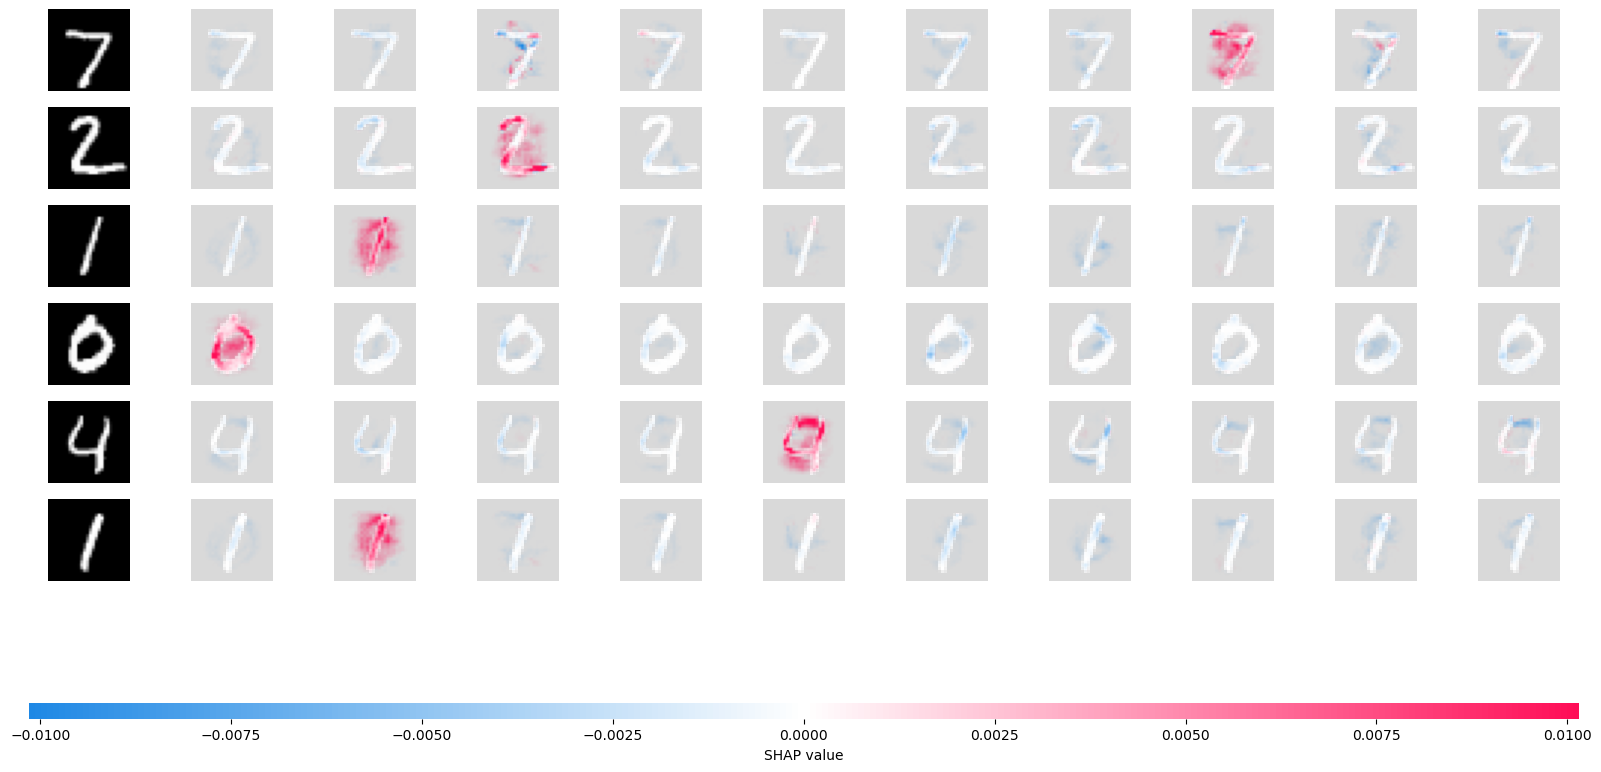

In [54]:
# select a set of background examples to take an expectation over
background = x_train[np.random.choice(x_train.shape[0], 100, replace=False)]

# get the test examples on which we want to evaluate shap values
image_examples = x_test[0:6]

deep_explainer = shap.DeepExplainer(model, background)
deep_shap_values = deep_explainer.shap_values(image_examples)

plot_shap_values(reshaped_shap_values=reshape_shap_values(deep_shap_values, number_of_classes=10),test_images=image_examples)

# GradientExplainer

### GradientExplainer is another alternative to explain deep learning model predictions. As it needs to compute gradients (derivatives), it can be however be only used with differential models. A disadvantage of GradientExplainer is that it can be slower to compute than the DeepExplainer.

/opt/anaconda3/envs/ibmi/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(50, 28, 28, 1))']
  warnings.warn(msg)


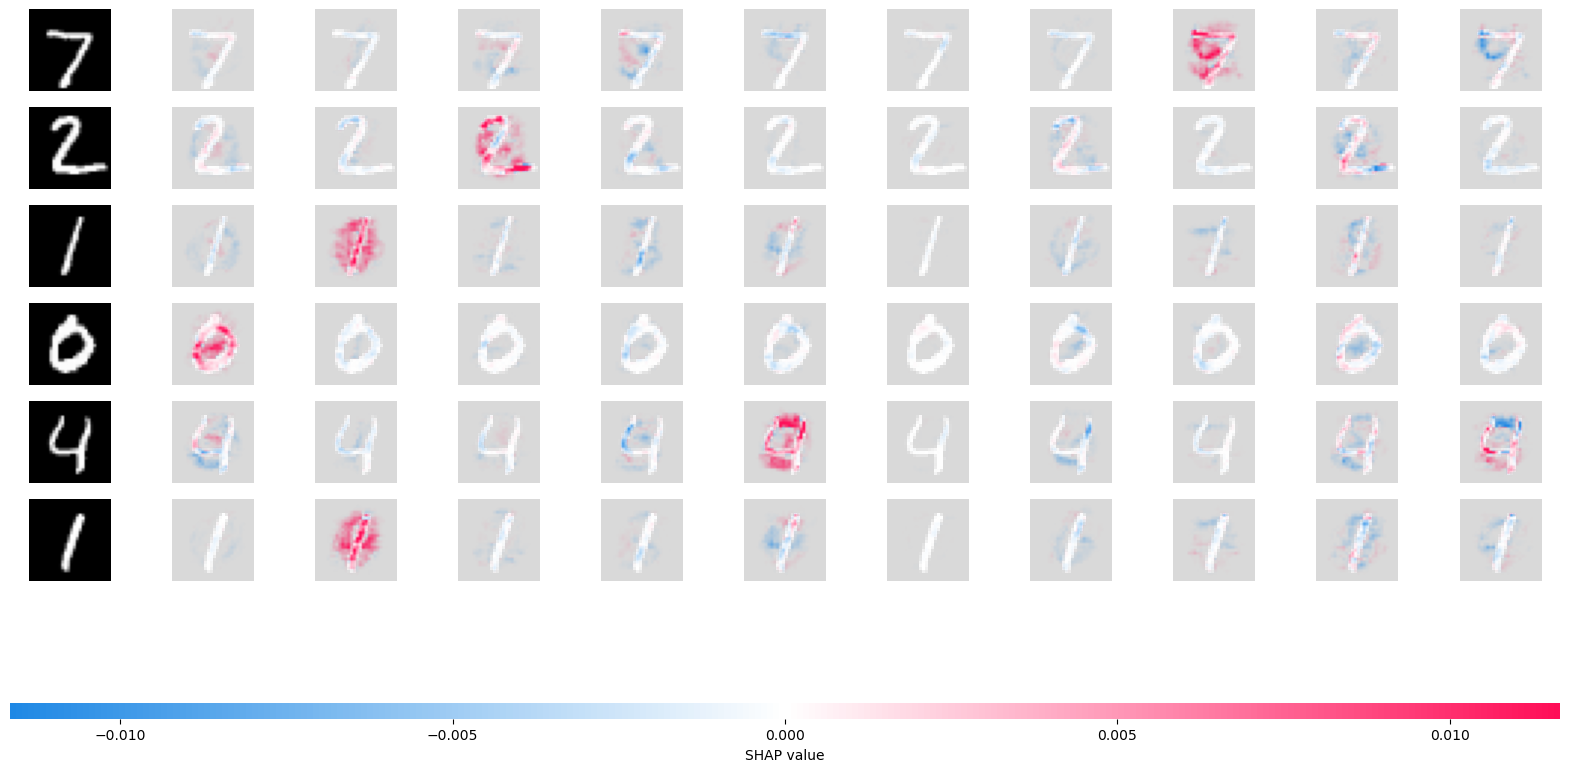

In [55]:
# select a set of background examples to take an expectation over
background = x_train[np.random.choice(x_train.shape[0], 100, replace=False)]

# get the test examples on which we want to evaluate shap values
image_examples = x_test[0:6]

grad_explainer = shap.GradientExplainer(model, background)
grad_shap_values = grad_explainer.shap_values(image_examples)

plot_shap_values(reshaped_shap_values=reshape_shap_values(grad_shap_values, number_of_classes=10),test_images=image_examples)